In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/processed/prices.csv", index_col="date", parse_dates=True)
log_prices = np.log(prices)
selected_pairs = pd.read_csv("../data/processed/selected_pairs.csv")
selected_pairs.shape

Matplotlib is building the font cache; this may take a moment.


(87, 4)

In [2]:
SIGNAL_WINDOW = 90

def compute_signals(price_a, price_b, window=SIGNAL_WINDOW):
    """Rolling hedge ratio (beta), spread, and z-score for a pair."""
    rolling_cov = price_a.rolling(window).cov(price_b)
    rolling_var = price_b.rolling(window).var()
    beta = rolling_cov / rolling_var

    alpha = price_a.rolling(window).mean() - beta * price_b.rolling(window).mean()
    spread = price_a - (alpha + beta * price_b)

    z_score = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()

    return pd.DataFrame({"beta": beta, "alpha": alpha, "spread": spread, "z_score": z_score})

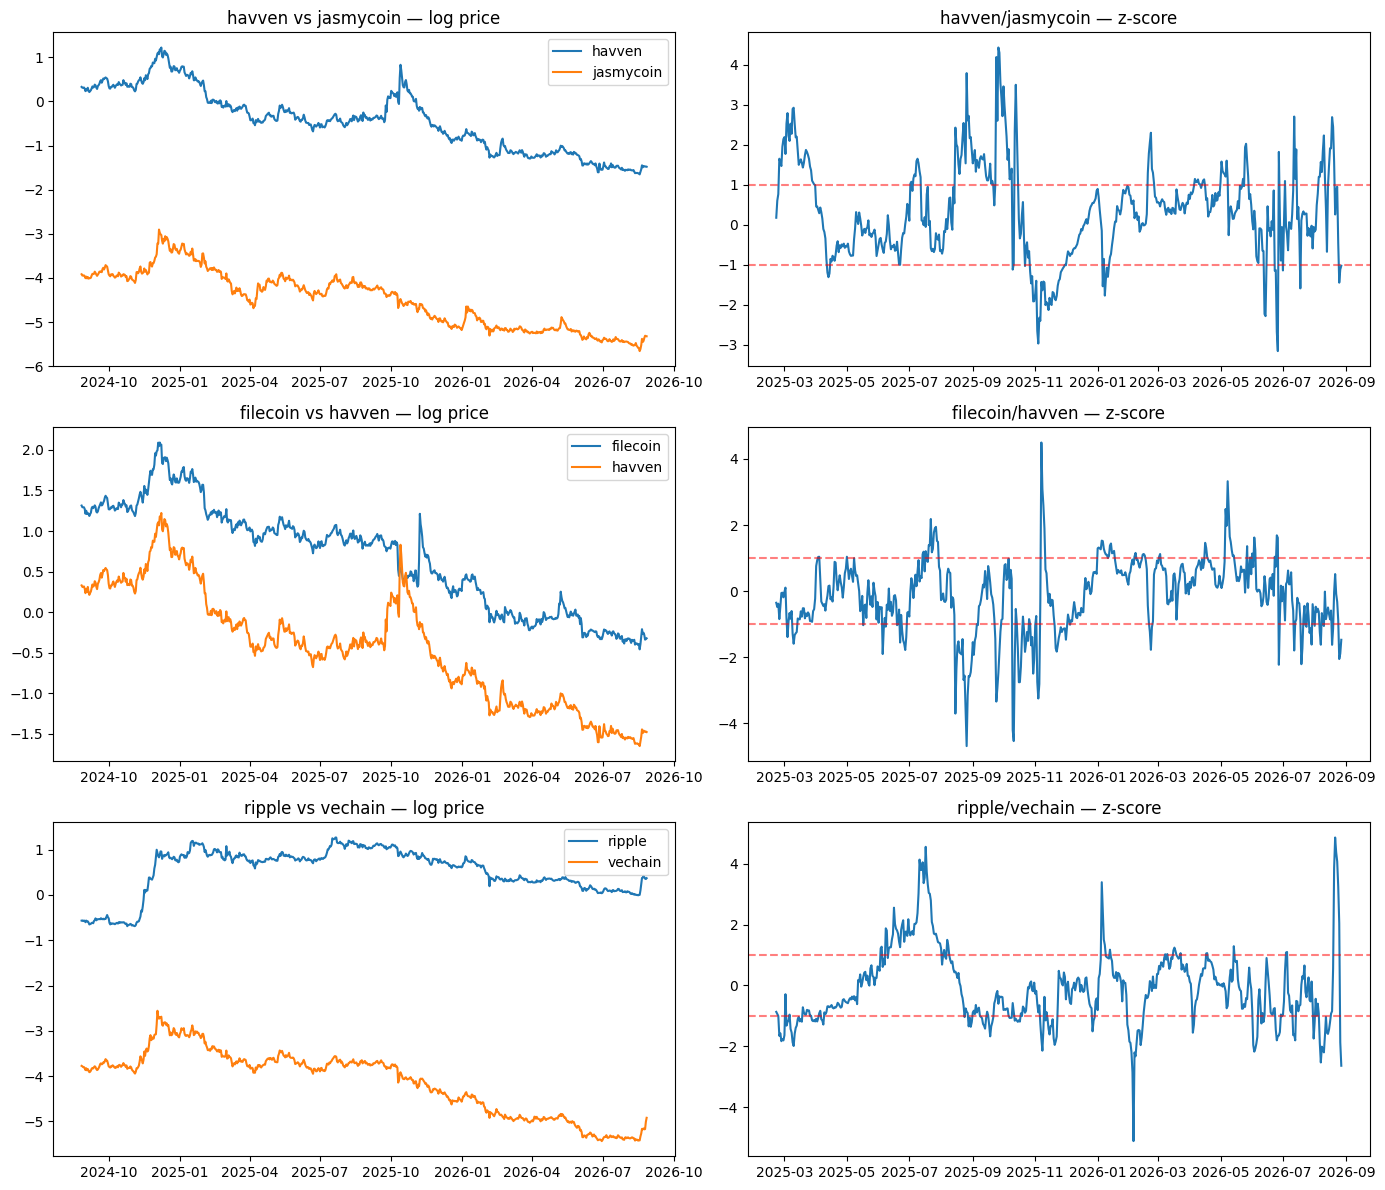

In [3]:
top_pairs = selected_pairs.sort_values("p_value").head(3)

fig, axes = plt.subplots(len(top_pairs), 2, figsize=(14, 4 * len(top_pairs)))

for i, (_, row) in enumerate(top_pairs.iterrows()):
    a, b = row["coin_a"], row["coin_b"]
    sig = compute_signals(log_prices[a], log_prices[b])

    axes[i, 0].plot(log_prices[a], label=a)
    axes[i, 0].plot(log_prices[b], label=b)
    axes[i, 0].set_title(f"{a} vs {b} — log price")
    axes[i, 0].legend()

    axes[i, 1].plot(sig["z_score"])
    axes[i, 1].axhline(1, color="red", linestyle="--", alpha=0.5)
    axes[i, 1].axhline(-1, color="red", linestyle="--", alpha=0.5)
    axes[i, 1].set_title(f"{a}/{b} — z-score")

plt.tight_layout()
plt.show()

In [4]:
all_signals = {}
for _, row in selected_pairs.iterrows():
    a, b = row["coin_a"], row["coin_b"]
    all_signals[(a, b)] = compute_signals(log_prices[a], log_prices[b])

print(f"Computed signals for {len(all_signals)} pairs")

Computed signals for 87 pairs


In [5]:
crossing_freq = {}
for pair, sig in all_signals.items():
    crossings = (sig["z_score"].abs() > 1).sum()
    crossing_freq[pair] = crossings

freq_series = pd.Series(crossing_freq).sort_values(ascending=False)
freq_series.describe()

count     87.000000
mean     189.505747
std       42.898440
min       47.000000
25%      158.000000
50%      195.000000
75%      220.000000
max      277.000000
dtype: float64